# Caixaverso - FC2 | Analista de Dados
## Projeto para o curso Técnicas de Programação I (PY) do 

### Aluno: Renato Tomio Yodono

#### Carregando e conhecendo o dataset

In [267]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [268]:
# Lendo o arquivo e salvando numa variável
df = pd.read_csv("UCI_Credit_Card.csv")

# Obtido em https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/
# em 17/04/2026

In [269]:
# Visão inicial do dataset
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [270]:
# Consultando o número de linhas, colunas, tipos e nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

#### Início do Data Wrangling

In [271]:
# Excluindo a coluna ID, pois não contribuirá com a análise
df.drop(columns=['ID'], inplace=True)

In [272]:
# Alterando o nome das colunas para português

df.columns = ['LIMITE_DO_CARTAO',
              'SEXO',
              'ESCOLARIDADE',
              'ESTADO_CIVIL',
              'IDADE',
              'STATUS_PAGAMENTO_0',
              'STATUS_PAGAMENTO_2',
              'STATUS_PAGAMENTO_3',
              'STATUS_PAGAMENTO_4',
              'STATUS_PAGAMENTO_5',
              'STATUS_PAGAMENTO_6',
              'VALOR_DA_FATURA_1',
              'VALOR_DA_FATURA_2',
              'VALOR_DA_FATURA_3',
              'VALOR_DA_FATURA_4',
              'VALOR_DA_FATURA_5',
              'VALOR_DA_FATURA_6',
              'VALOR_PAGO_1',
              'VALOR_PAGO_2',
              'VALOR_PAGO_3',
              'VALOR_PAGO_4',
              'VALOR_PAGO_5',
              'VALOR_PAGO_6',
              'INADIMPLENTE']

In [273]:
# Dicionário de dados, conforme fornecido pelo Kaggle, para verificação de valores inválidos para as variáveis categóricas
# As atribuições abaixo foram baseadas nas informações fornecidaas no Kaggle nos links abaixo:
# https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
# https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608

valores_validos = {'SEXO': [1,2],
                   'ESCOLARIDADE': [1,2,3,4],
                   'ESTADO_CIVIL': [0,1,2,3],
                   'STATUS_PAGAMENTO_0': list(range(-2,10)),
                   'STATUS_PAGAMENTO_2': list(range(-2,10)),
                   'STATUS_PAGAMENTO_3': list(range(-2,10)),
                   'STATUS_PAGAMENTO_4': list(range(-2,10)),
                   'STATUS_PAGAMENTO_5': list(range(-2,10)),
                   'STATUS_PAGAMENTO_6': list(range(-2,10)),
                   'INADIMPLENTE': [0,1]}

# Tratamento a ser dado aos valores inválidos das variáveis categóricas:
    
    # SEXO: atribuir nan
    # ESCOLARIDADE: atribuir o valor 4 (outros)
    # ESTADO-CIVIL: atribuir o valor 0 (outros)
    # STATUS_PAGAMENTO_0: atribuir nan
    # STATUS_PAGAMENTO_2: atribuir nan
    # STATUS_PAGAMENTO_3: atribuir nan
    # STATUS_PAGAMENTO_4: atribuir nan
    # STATUS_PAGAMENTO_5: atribuir nan
    # STATUS_PAGAMENTO_6: atribuir nan
    # INADIMPLENTE: atribuir nan

tratar_valores_invalidos = {'SEXO': np.nan,
                   'ESCOLARIDADE': 4,
                   'ESTADO_CIVIL': 0,
                   'STATUS_PAGAMENTO_0': np.nan,
                   'STATUS_PAGAMENTO_2': np.nan,
                   'STATUS_PAGAMENTO_3': np.nan,
                   'STATUS_PAGAMENTO_4': np.nan,
                   'STATUS_PAGAMENTO_5': np.nan,
                   'STATUS_PAGAMENTO_6': np.nan,
                   'INADIMPLENTE': np.nan}

# Para as variáveis quantitativas definiremos como valores válidos:

    # IDADE: maior que 18 e menor que 120
        #Tratamento a ser dado: atribuir nan

    # LIMITE_DO_CARTAO: maior ou igual a zero
    # VALOR_DA_FATURA_1: maior ou igual a zero
    # VALOR_DA_FATURA_2: maior ou igual a zero
    # VALOR_DA_FATURA_3: maior ou igual a zero
    # VALOR_DA_FATURA_4: maior ou igual a zero
    # VALOR_DA_FATURA_5: maior ou igual a zero
    # VALOR_DA_FATURA_6: maior ou igual a zero
    # VALOR_PAGO_1: maior ou igual a zero
    # VALOR_PAGO_2: maior ou igual a zero
    # VALOR_PAGO_3: maior ou igual a zero
    # VALOR_PAGO_4: maior ou igual a zero
    # VALOR_PAGO_5: maior ou igual a zero
    # VALOR_PAGO_6: maior ou igual a zero

    # Tratamento a ser dado ao valores inválidos: atribuir zero

variaveis_quantitativas = ['LIMITE_DO_CARTAO',
                           'VALOR_DA_FATURA_1',
                           'VALOR_DA_FATURA_2',
                           'VALOR_DA_FATURA_3',
                           'VALOR_DA_FATURA_4',
                           'VALOR_DA_FATURA_5',
                           'VALOR_DA_FATURA_6',
                           'VALOR_PAGO_1',
                           'VALOR_PAGO_2',
                           'VALOR_PAGO_3',
                           'VALOR_PAGO_4',
                           'VALOR_PAGO_5',
                           'VALOR_PAGO_6']

In [274]:
# Tratamento de valores inválidos

for coluna, valor in valores_validos.items():
    df.loc[~(df[coluna].isin(valor)), coluna] = tratar_valores_invalidos[coluna]

df.loc[(df['IDADE'] < 18) | (df['IDADE'] > 120), 'IDADE'] = np.nan

for coluna in variaveis_quantitativas:
    df.loc[df[coluna] < 0, coluna] = 0


In [275]:
# Alterando os tipos das variáveis e renomeando as categóricas para melhorar a legibilidade
df['SEXO'] = df['SEXO'].astype(int)
df['SEXO'] = df['SEXO'].astype(str)
df.loc[df['SEXO'] == '1', 'SEXO'] = 'Masculino'
df.loc[df['SEXO'] == '2', 'SEXO'] = 'Feminino'

df['IDADE'] = df['IDADE'].astype(int)

df['ESCOLARIDADE'] = df['ESCOLARIDADE'].astype(str)
df.loc[df['ESCOLARIDADE'] == '1', 'ESCOLARIDADE'] = 'Pós-graduação'
df.loc[df['ESCOLARIDADE'] == '2', 'ESCOLARIDADE'] = 'Graduação'
df.loc[df['ESCOLARIDADE'] == '3', 'ESCOLARIDADE'] = 'Ensino Médio'
df.loc[df['ESCOLARIDADE'] == '4', 'ESCOLARIDADE'] = 'Outros'

df['ESTADO_CIVIL'] = df['ESTADO_CIVIL'].astype(str)
df.loc[df['ESTADO_CIVIL'] == '0', 'ESTADO_CIVIL'] = 'Outros'
df.loc[df['ESTADO_CIVIL'] == '1', 'ESTADO_CIVIL'] = 'Casado'
df.loc[df['ESTADO_CIVIL'] == '2', 'ESTADO_CIVIL'] = 'Solteiro'
df.loc[df['ESTADO_CIVIL'] == '3', 'ESTADO_CIVIL'] = 'Divorciado'

for item in df.columns[5:11]:
    df[item] = df[item].astype(int)
    df[item] = df[item].astype(str)
    df.loc[df[item] == '-2', item] = 'Sem consumo'
    df.loc[df[item] == '-1', item] = 'Pagamento total'
    df.loc[df[item] == '0', item] = 'Uso do rotativo'
    df.loc[df[item] == '1', item] = '1 mês de atraso'
    df.loc[df[item] == '2', item] = '2 meses de atraso'
    df.loc[df[item] == '3', item] = '3 meses de atraso'
    df.loc[df[item] == '4', item] = '4 meses de atraso'
    df.loc[df[item] == '5', item] = '5 meses de atraso'
    df.loc[df[item] == '6', item] = '6 meses de atraso'
    df.loc[df[item] == '7', item] = '7 meses de atraso'
    df.loc[df[item] == '8', item] = '8 meses de atraso'
    df.loc[df[item] == '9', item] = '9 meses de atraso'

df['INADIMPLENTE'] = df['INADIMPLENTE'].astype(int)
df['INADIMPLENTE'] = df['INADIMPLENTE'].astype(str)
df.loc[df['INADIMPLENTE'] == '0', 'INADIMPLENTE'] = 'Não'
df.loc[df['INADIMPLENTE'] == '1', 'INADIMPLENTE'] = 'Sim'

In [276]:
df.head()

,LIMITE_DO_CARTAO,SEXO,ESCOLARIDADE,ESTADO_CIVIL,IDADE,STATUS_PAGAMENTO_0,STATUS_PAGAMENTO_2,STATUS_PAGAMENTO_3,STATUS_PAGAMENTO_4,STATUS_PAGAMENTO_5,...,VALOR_DA_FATURA_4,VALOR_DA_FATURA_5,VALOR_DA_FATURA_6,VALOR_PAGO_1,VALOR_PAGO_2,VALOR_PAGO_3,VALOR_PAGO_4,VALOR_PAGO_5,VALOR_PAGO_6,INADIMPLENTE
0,20000.0,Feminino,Graduação,Casado,24,2 meses de atraso,2 meses de atraso,Pagamento total,Pagamento total,Sem consumo,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,Sim
1,120000.0,Feminino,Graduação,Solteiro,26,Pagamento total,2 meses de atraso,Uso do rotativo,Uso do rotativo,Uso do rotativo,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,Sim
2,90000.0,Feminino,Graduação,Solteiro,34,Uso do rotativo,Uso do rotativo,Uso do rotativo,Uso do rotativo,Uso do rotativo,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,Não
3,50000.0,Feminino,Graduação,Casado,37,Uso do rotativo,Uso do rotativo,Uso do rotativo,Uso do rotativo,Uso do rotativo,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,Não
4,50000.0,Masculino,Graduação,Casado,57,Pagamento total,Uso do rotativo,Pagamento total,Uso do rotativo,Uso do rotativo,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,Não


In [277]:
# Estatísticas descritivas. Consulta após limpeza do dataset.
df.describe()

,LIMITE_DO_CARTAO,IDADE,VALOR_DA_FATURA_1,VALOR_DA_FATURA_2,VALOR_DA_FATURA_3,VALOR_DA_FATURA_4,VALOR_DA_FATURA_5,VALOR_DA_FATURA_6,VALOR_PAGO_1,VALOR_PAGO_2,VALOR_PAGO_3,VALOR_PAGO_4,VALOR_PAGO_5,VALOR_PAGO_6
count,30000.000000,30000.000000,30000.00000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51246.04190,49206.518033,4.704517e+04,43299.651933,40347.092100,38942.268767,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73608.02908,71150.744613,6.931878e+04,64294.968472,60766.619726,59445.970807,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,0.00000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.75000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.50000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.00000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.00000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


# Perguntas sobre o dataset

In [278]:
# Inadimplência Geral

inad_geral = df['INADIMPLENTE'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %'
inad_geral

INADIMPLENTE
Não    77.88 %
Sim    22.12 %
Name: proportion, dtype: str

In [279]:
# Inadimplência por sexo

inad_por_sexo = df.groupby('SEXO')['INADIMPLENTE'].value_counts(normalize=True).mul(100).round(2)
inad_por_sexo = inad_por_sexo[[('Feminino','Sim'),('Masculino','Sim')]]
inad_por_sexo

SEXO       INADIMPLENTE
Feminino   Sim             20.78
Masculino  Sim             24.17
Name: proportion, dtype: float64

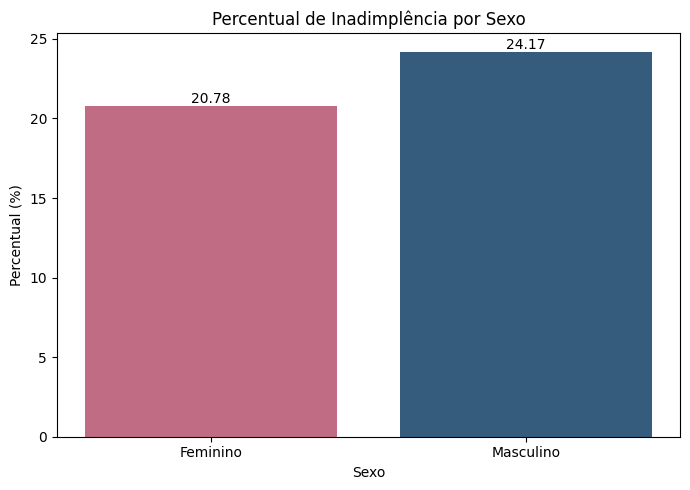

In [280]:
# Gráfico
plot_df = inad_por_sexo.reset_index()
plot_df.columns = ['SEXO', 'INADIMPLENTE', 'PERCENTUAL']

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(plot_df['SEXO'], plot_df['PERCENTUAL'], color=['#C06C84', '#355C7D'])

plt.title('Percentual de Inadimplência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

In [281]:
# Inadimplência por escolaridade

inad_por_escolaridade = df.groupby('ESCOLARIDADE')['INADIMPLENTE'].value_counts(normalize=True).mul(100).round(2)
inad_por_escolaridade = inad_por_escolaridade[[('Ensino Médio', 'Sim'), ('Graduação', 'Sim'),('Pós-graduação', 'Sim'),('Outros', 'Sim')]]

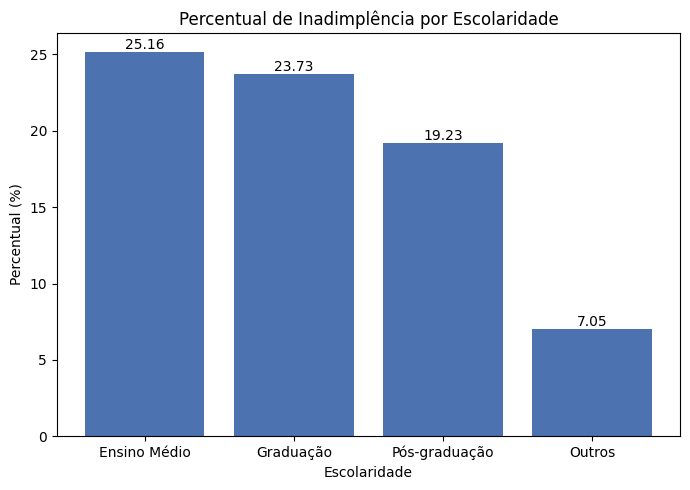

In [282]:
# Gráfico
plot_df = inad_por_escolaridade.reset_index()
plot_df.columns = ['ESCOLARIDADE', 'INADIMPLENTE', 'PERCENTUAL']

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(plot_df['ESCOLARIDADE'], plot_df['PERCENTUAL'], color='#4C72B0')

plt.title('Percentual de Inadimplência por Escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

In [283]:
inad_por_estado_civil = df.groupby('ESTADO_CIVIL')['INADIMPLENTE'].value_counts(normalize=True).mul(100).round(2)
inad_por_estado_civil = inad_por_estado_civil[[('Outros', 'Sim'), ('Casado', 'Sim'),('Solteiro', 'Sim'),('Divorciado', 'Sim')]]

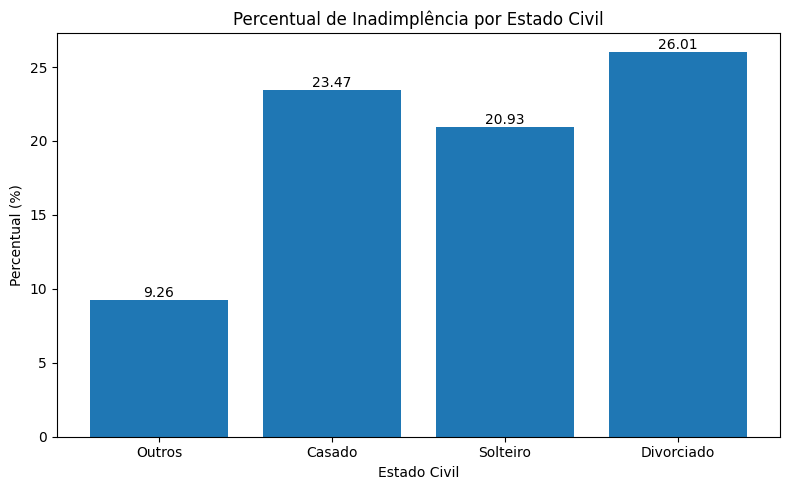

In [284]:
# Gráfico
plot_df = inad_por_estado_civil.reset_index()
plot_df.columns = ['ESTADO_CIVIL', 'INADIMPLENTE', 'PERCENTUAL']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(plot_df['ESTADO_CIVIL'], plot_df['PERCENTUAL'])

plt.title('Percentual de Inadimplência por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

In [285]:
# Distribuição dos inadimplentes por limite de cartão
lc_sim = df[df['INADIMPLENTE'] == 'Sim']['LIMITE_DO_CARTAO'].agg(['min','median', 'max', 'mean', 'std']).round(2)
lc_geral = df['LIMITE_DO_CARTAO'].agg(['min','median', 'max', 'mean', 'std']).round(2)

comparacao1 = pd.concat([lc_geral, lc_sim], axis=1)
comparacao1.columns = ['Geral', 'Inadimplentes_Sim']

comparacao1

,Geral,Inadimplentes_Sim
min,10000.00,10000.00
median,140000.00,90000.00
max,1000000.00,740000.00
mean,167484.32,130109.66
std,129747.66,115378.54


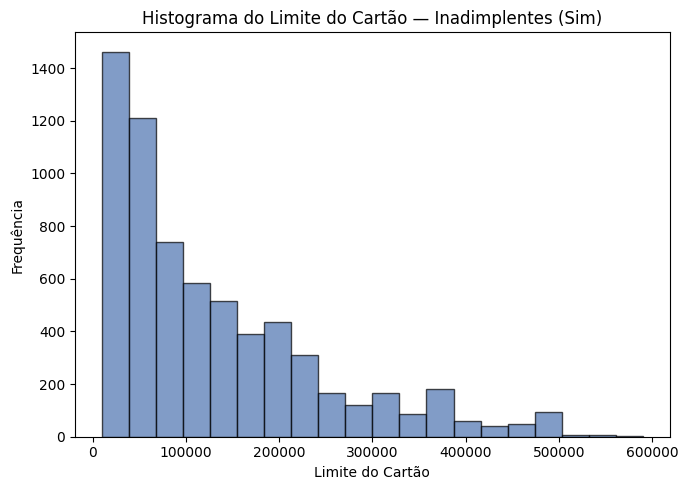

In [286]:
# Histograma
dados = df[(df['INADIMPLENTE'] == 'Sim') & (df['LIMITE_DO_CARTAO'] < 600000.00)]['LIMITE_DO_CARTAO']

plt.figure(figsize=(7,5))
plt.hist(dados, bins=20, color='#4C72B0', edgecolor='black', alpha=0.7)

plt.title('Histograma do Limite do Cartão — Inadimplentes (Sim)')
plt.xlabel('Limite do Cartão')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


In [287]:
# Distribuição dos inadimplentes por idade
idade_sim = df[df['INADIMPLENTE'] == 'Sim']['IDADE'].agg(['min','median', 'max', 'mean', 'std']).round(2)
idade_geral = df['IDADE'].agg(['min','median', 'max', 'mean', 'std']).round(2)

comparacao2 = pd.concat([idade_geral, idade_sim], axis=1)
comparacao2.columns = ['Geral', 'Inadimplentes_Sim']

comparacao2


,Geral,Inadimplentes_Sim
min,21.00,21.00
median,34.00,34.00
max,79.00,75.00
mean,35.49,35.73
std,9.22,9.69


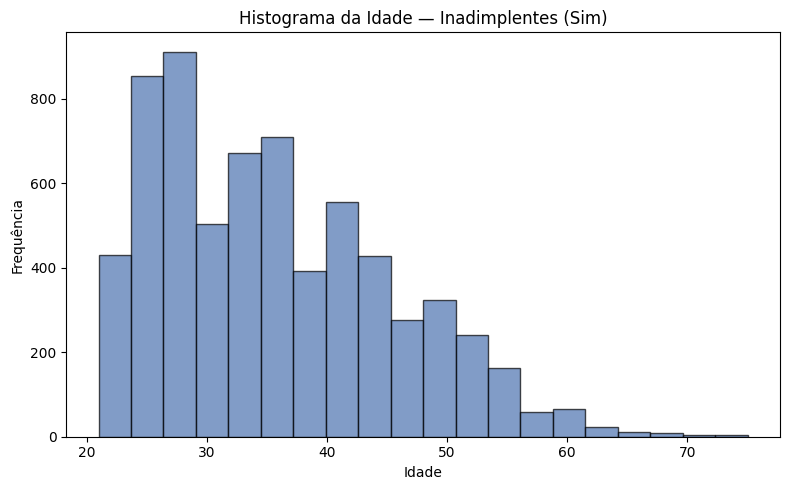

In [288]:
# Histograma

idades = df[df['INADIMPLENTE'] == 'Sim']['IDADE']

plt.figure(figsize=(8,5))
plt.hist(idades, bins=20, color='#4C72B0', edgecolor='black', alpha=0.7)

plt.title('Histograma da Idade — Inadimplentes (Sim)')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


### CONCLUSÕES

1. A inadimplência entre os homens é superior à das mulheres e superior à inadimplência geral;
2. Existe uma tendência de que quanto maior a escolaridade, menor a inadimplência;
3. Casados e divorciados apresentaram inadimplência acima da inadimplência geral;
4. Existe uma tendência de haver mais inadimplência nos cartões com limites mais baixos (média e mediana dos inadimplentes é inferior à média e mediana geral);
5. A idade não parece interferir muito na inadimplência, pois as estatísticas descritivas dos inadimplentes é semelhante às de todos os cartões.